In [2]:
import torch
import numpy as np
import networkx as nx
import seaborn as sns

import matplotlib.pyplot as plt

In [3]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

# Import dataset from PyTorch Geometric
dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

# Print information
print(dataset)
print('------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print first element
print(f'Graph: {dataset[0]}')
data = dataset[0]

/home/filipe-silva/redes_grafos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cora()
------------
Number of graphs: 1
Number of features: 1433
Number of classes: 7
Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


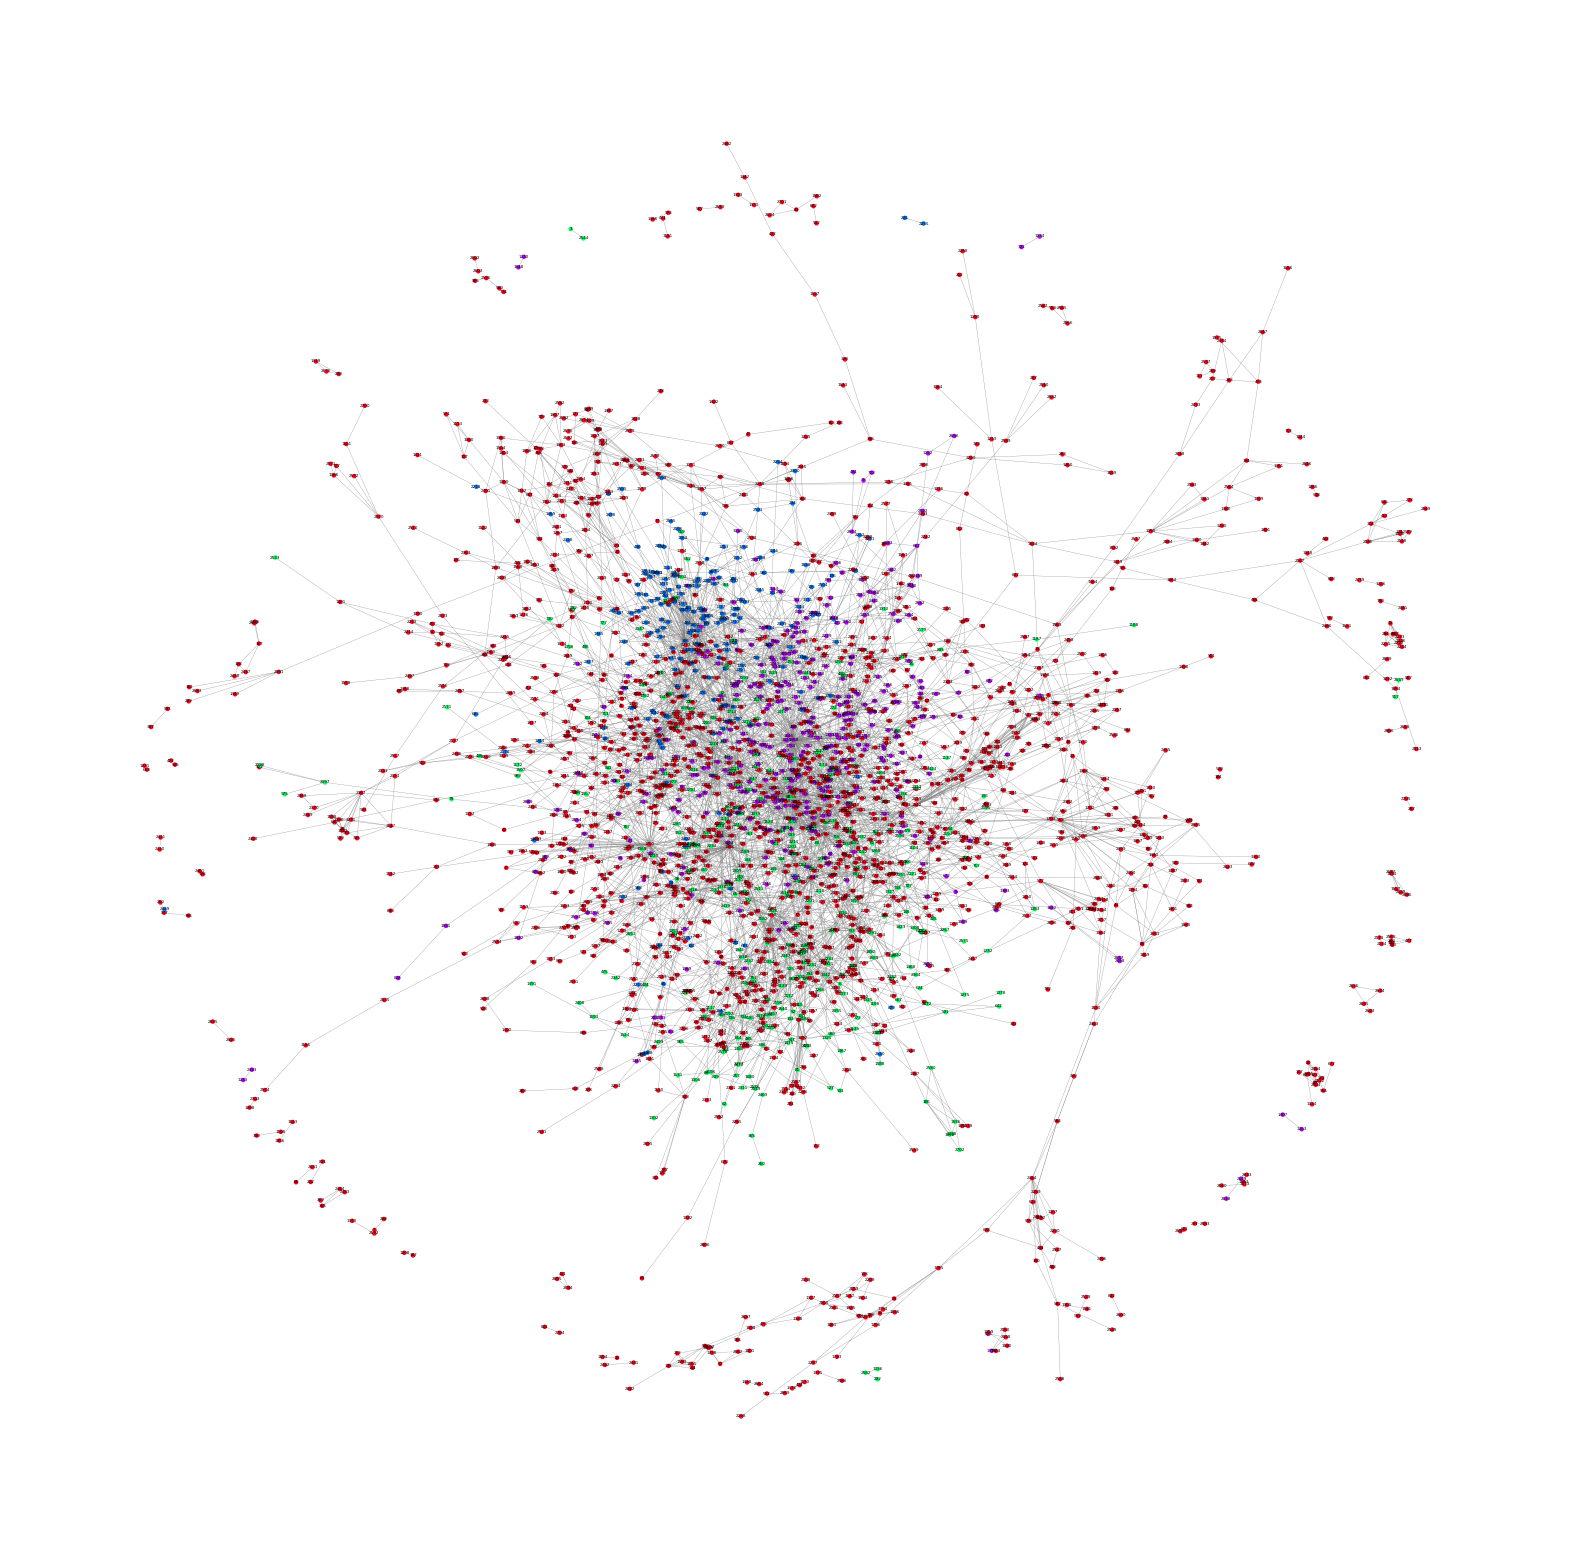

In [4]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
plt.figure(figsize=(20,20))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=True,
                node_size=5,
                node_color=data.y,
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.2,
                edge_color="grey",
                font_size=3
                )
plt.show()

edge_index = torch.Size([2, 10556])


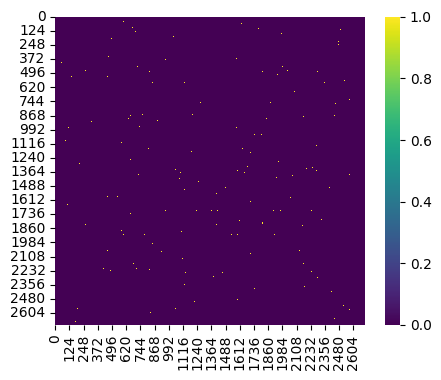

torch.Size([1, 2708, 2708])


In [4]:
from torch_geometric.utils import to_dense_adj 
print(f'edge_index = {data.edge_index.shape}')
adj = to_dense_adj(data.edge_index)

plt.figure(figsize=(5, 4))
sns.heatmap(adj.squeeze(0), cmap="viridis", vmin=0, vmax=1)
plt.show()
print(adj.shape)

In [86]:
def sharp_sigmoid(x, sharpness=50, threshold=0.1):
    return torch.sigmoid(sharpness * (x - threshold))

In [95]:
from torch_geometric.nn import DenseGCNConv
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F

class DenseGCN(torch.nn.Module):
    def __init__(self, adj):
        super().__init__()
        
        self.adj_param = nn.Parameter(adj.clone().float())

        self.gcn1 = DenseGCNConv(1433, 64) 
        self.gcn2 = DenseGCNConv(64, 7)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x):
        # adj_positive = F.sigmoid(self.adj_param)
        adj_positive = sharp_sigmoid(self.adj_param) # F.softmax(self.adj_param, dim=-1)
        # adj_positive = gumbel_sigmoid(self.adj_param)
        
        olho = torch.eye(adj_positive.size(-1), device=adj_positive.device)
        adj_positive = adj_positive * (1 - olho)
        
        adj_norm = self.normalize_adj(adj_positive)
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        
        return x


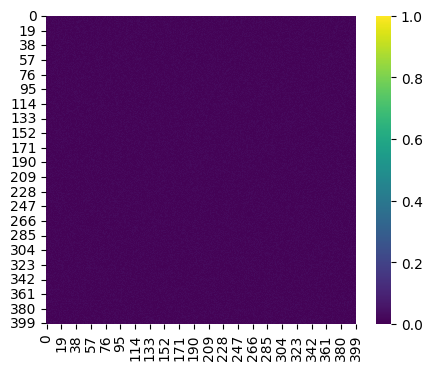

Epoch   0 | Loss: 2.08 | Acc: 27.75%


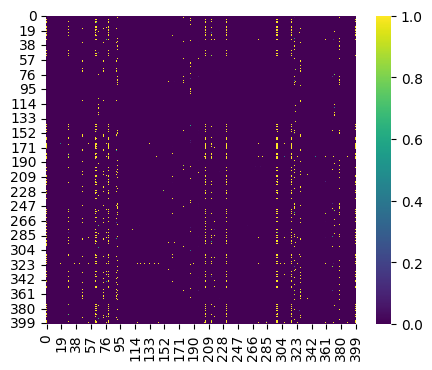

Epoch  50 | Loss: 0.11 | Acc: 99.25%


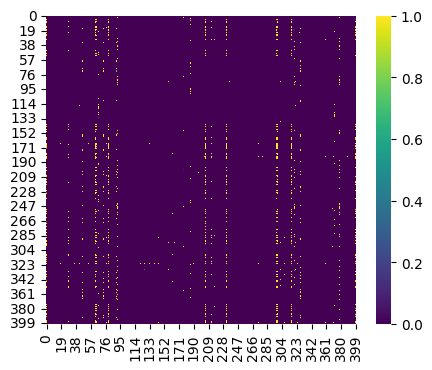

Epoch 100 | Loss: 0.06 | Acc: 100.00%


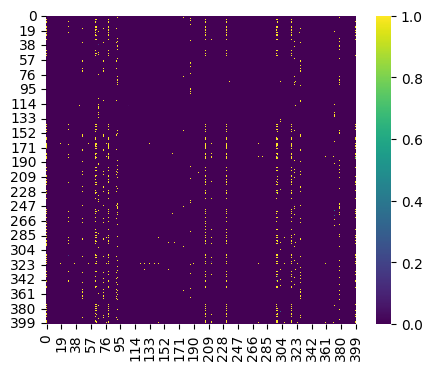

Epoch 150 | Loss: 0.05 | Acc: 100.00%


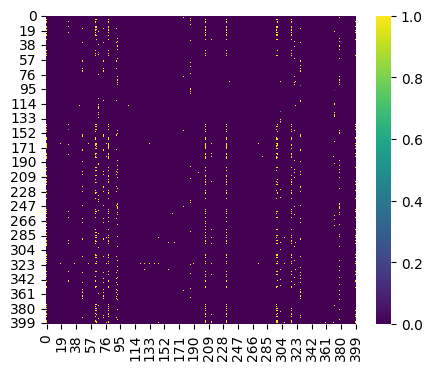

Epoch 200 | Loss: 0.05 | Acc: 100.00%


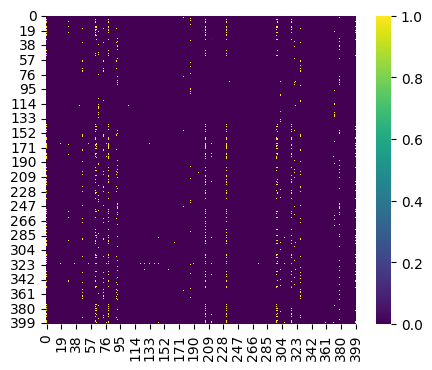

Epoch 250 | Loss: 0.04 | Acc: 100.00%


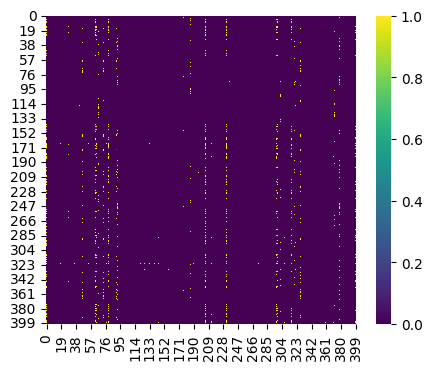

Epoch 300 | Loss: 0.04 | Acc: 100.00%


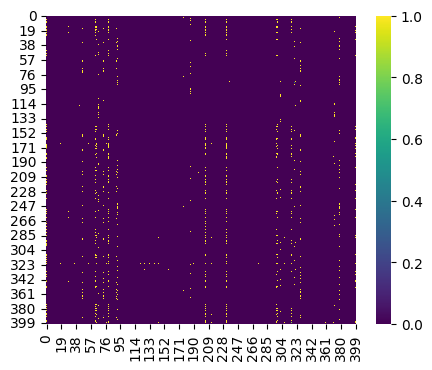

Epoch 350 | Loss: 0.04 | Acc: 100.00%


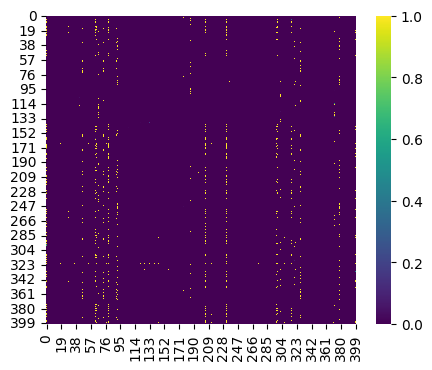

Epoch 400 | Loss: 0.04 | Acc: 100.00%


In [ ]:
num_nos_mini = 400

x_mini = data.x[:num_nos_mini].unsqueeze(0).to('cuda')
y_mini = data.y[:num_nos_mini].to('cuda')
mask_mini = data.train_mask[:num_nos_mini].to('cuda')

adj_inicial = torch.rand((num_nos_mini, num_nos_mini)) * 0.04 + 0.01
adj_inicial = adj_inicial.unsqueeze(0).to('cuda')

model = DenseGCN(adj_inicial).to('cuda')
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []

# Training loop
for epoch in range(401):
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    z = model(x_mini)
    z = z.squeeze(0)
    # Calculate loss function
    loss = criterion(z, y_mini) + sharp_sigmoid(model.adj_param).sum() * 0.00005 # Regularization term

    # Calculate accuracy
    acc = accuracy(z.argmax(dim=1), y_mini)

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    losses.append(loss)
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    # Print metrics every 10 epochs
    if epoch % 50 == 0:
        adj_now = sharp_sigmoid(model.adj_param).detach().cpu().numpy()
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj_now.squeeze(0), cmap="viridis", vmin=0, vmax=1)
        plt.show()
        print(f'Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%')
    # if acc == 1.0:
    #     print(f'Perfect accuracy reached at epoch {epoch}. Stopping training.')
    #     break

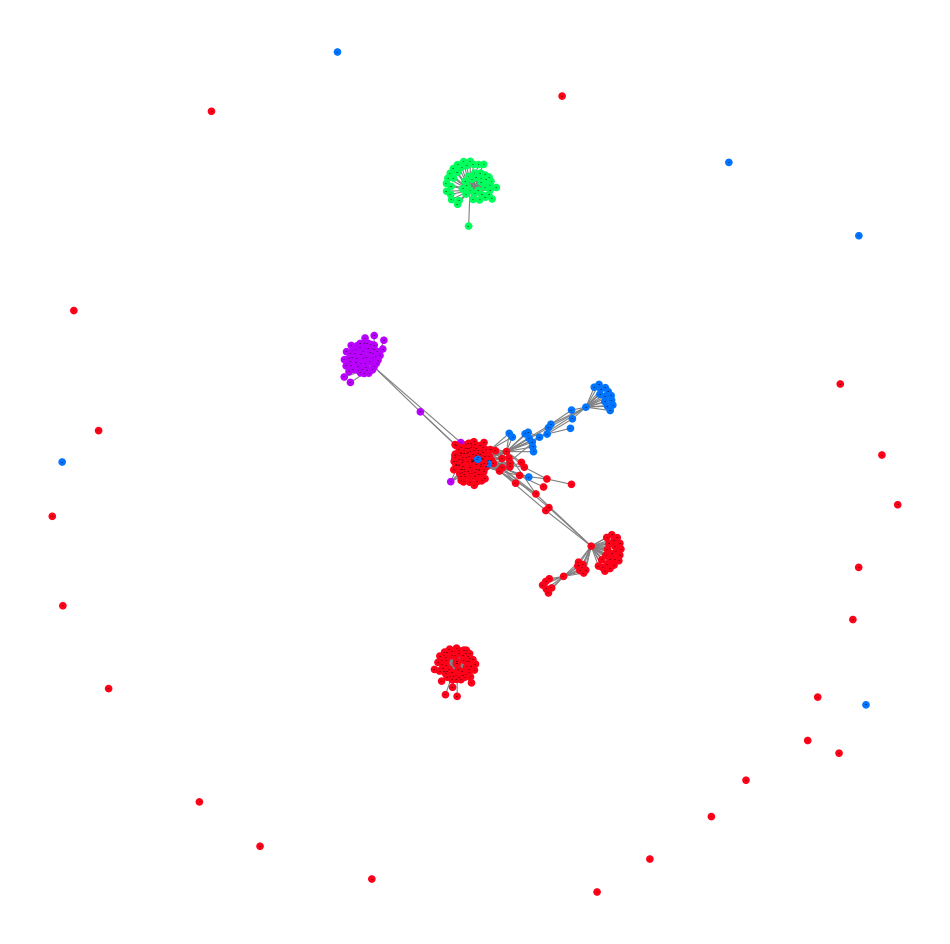

In [101]:
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data 
from torch_geometric.utils import to_networkx
import torch
adj = sharp_sigmoid(model.adj_param).detach().cpu().squeeze(0).numpy()

adj = np.where(adj > 0.7,1, 0)

edge_index, edge_weight = dense_to_sparse(torch.from_numpy(adj))
data_view = Data(edge_index=edge_index,num_nodes=400)


G = to_networkx(data_view, to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G, seed=0),
                with_labels=True,
                node_size=20,
                node_color=y_mini.cpu().numpy(),
                cmap="hsv",
                vmin=-2,
                vmax=3,
                width=0.8,
                edge_color="grey",
                font_size=1
                )
plt.show()

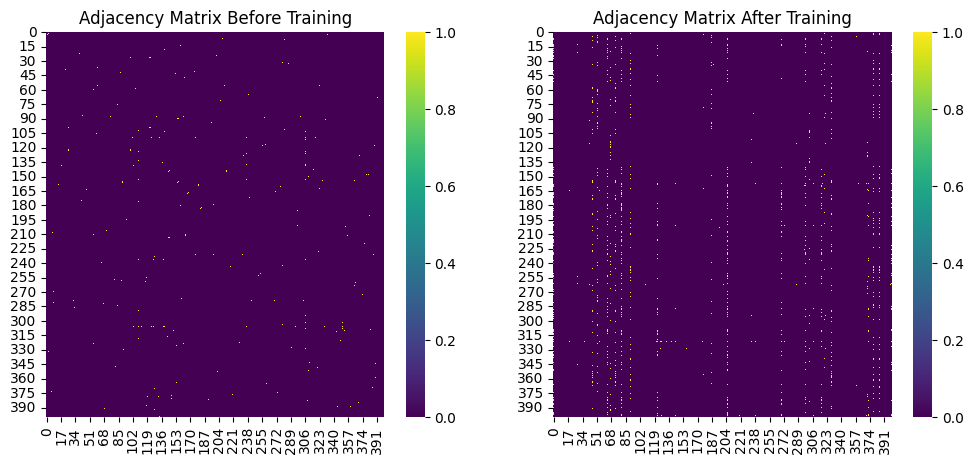

In [102]:
adj_treino  = sharp_sigmoid(model.adj_param, 50).detach().cpu().numpy().squeeze(0)
adj_treino = np.where(adj_treino >= 0.7,1, 0)

adj_original = to_dense_adj(data.edge_index).squeeze(0).numpy()
adj_original = adj_original[:num_nos_mini, :num_nos_mini]  # Ajustar para o tamanho do mini-grafo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(adj_original, cmap="viridis", vmin=0, vmax=1)
plt.title("Adjacency Matrix Before Training")
plt.subplot(1, 2, 2)
sns.heatmap(adj_treino, cmap="viridis", vmin=0, vmax=1)
plt.title("Adjacency Matrix After Training")
plt.show()  

In [103]:
matriz_classes_iguais = (y_mini.unsqueeze(0) == y_mini.unsqueeze(1))

olho = torch.eye(num_nos_mini, dtype=torch.bool, device=y_mini.device)

matriz_gabarito = matriz_classes_iguais & (~olho)

total_esperado = (matriz_gabarito.sum().item())//2


linhas,colunas = torch.where(torch.from_numpy(adj_treino) == 1)
ligacoes_corretas = 0
ligacoes_totais_validas = 0

for i in range(len(linhas)):
    no_A = linhas[i].item()
    no_B = colunas[i].item()

    if no_A != no_B:
        ligacoes_totais_validas += 1
        
        if y_mini[no_A] == y_mini[no_B]:
            ligacoes_corretas += 1

ligacoes_perdidas = total_esperado - ligacoes_corretas
recall = (ligacoes_corretas / total_esperado) * 100 if total_esperado > 0 else 0

print(f"Total de ligações esperadas: {total_esperado}")
print(f"Total de ligações feitas pela rede: {ligacoes_totais_validas}")
print(f"A rede fez {ligacoes_corretas} ligações corretas. Precisão: {ligacoes_corretas / ligacoes_totais_validas * 100:.2f}%")
print(f"Ela deveria ter feito {ligacoes_perdidas} ligações corretas.")
print(f"Recall: {recall:.2f}%")


Total de ligações esperadas: 13418
Total de ligações feitas pela rede: 1457
A rede fez 1126 ligações corretas. Precisão: 77.28%
Ela deveria ter feito 12292 ligações corretas.
Recall: 8.39%


In [85]:
total_1 = np.sum(adj_original)
total_2 = np.sum(adj_treino)
interseção = np.sum(np.logical_and(adj_original, adj_treino))

p1 = (interseção / total_1 * 100) if total_1 > 0 else 0

p2 = (interseção / total_2 * 100) if total_2 > 0 else 0

p1_exclusiva = 100 - p1 if total_1 > 0 else 0

p2_exclusiva = 100 - p2 if total_2 > 0 else 0

print(f"Arestas da original que estão na treinada {p1:.1f}%")
print(f"Arestas da treinada que estão na original: {p2:.1f}%")
print(f"Arestas da original que NÃO estão na treinada: {p1_exclusiva:.1f}%")
print(f"Arestas da treinada que NÃO estão na original: {p2_exclusiva:.1f}%")

Arestas da original que estão na treinada 2.2%
Arestas da treinada que estão na original: 0.8%
Arestas da original que NÃO estão na treinada: 97.8%
Arestas da treinada que NÃO estão na original: 99.2%
